# Family-Aware BERT Error Attribution (Integrated Gradients)

Notebook 12's Section 8 showed that character/token length alone does not explain most of
BERT's 6 test-set errors. This notebook goes to word level: for each erroring case, it uses
**Integrated Gradients (IG)** -- via [captum](https://captum.ai/), applied directly to the
frozen family-aware BERT checkpoint's word embeddings -- to identify which words actually
pushed the prediction toward the wrong agency, and contrasts that against a correctly
classified condition of the *same* document.

**Why Integrated Gradients, not attention or word clouds:** attention weights show what a
layer attends to, not what causally influenced the output logit, and are well documented in
the interpretability literature as unreliable explanations of a prediction on their own. IG
instead measures how much each input word's embedding contributed to moving the model's
output from a neutral baseline to its actual prediction -- a gradient-based, per-class
causal-attribution method, which is what this analysis needs.

**This notebook runs the frozen model for inference and gradient computation only.** It
loads `artifacts/family_aware/models/3e4c71a6758249aabe262fa12e39cce4/checkpoint/` (the same
saved checkpoint used everywhere else in this project) via
`AutoModelForSequenceClassification.from_pretrained`. Integrated Gradients requires
backpropagating gradients through the model to compute attributions, but **no optimizer step
ever runs and no weight is ever updated** -- this is the same category of operation as
`BERTClassifier.predict_proba()`, just with gradients kept instead of discarded. No training,
no new data, no API calls.

**New dependency:** `captum` (installed in the `newstart-ai` environment for this notebook;
not used elsewhere in the project).

**Method, case by case:**
1. For each of the 6 real BERT test-set errors, pick a **same-document, correctly classified
   condition** as the comparison case (the `middle_only` condition of matching mask status,
   which had a 0% error rate for every document in the test set; the one `complete_masked`
   error is compared against that document's `complete_unmasked` result instead).
2. **Reproduce every recorded prediction from scratch first** (a plain forward pass, no
   gradients) and check it matches the real saved prediction in
   `checkpoint8_test_predictions.csv` exactly -- IG attributions are only trustworthy if they
   explain a prediction this notebook can independently reproduce.
3. Run Layer Integrated Gradients on each case's input embeddings, targeting the predicted
   class, and merge WordPiece sub-tokens back into whole words.
4. Compare the top attributed words between the erroring condition and the correct
   comparison condition for the same document.

## Setup: load the frozen checkpoint and the saved evaluation artifacts

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from captum.attr import LayerIntegratedGradients
from transformers import AutoModelForSequenceClassification, AutoTokenizer

sys.path.insert(0, str(Path("..") / "src"))
from newstart_ai.config import load_settings

settings = load_settings()
LABEL_ORDER = list(settings.base.labels)
MAX_TOKENS = settings.base.long_document_strategy.max_tokens

checkpoint_dir = settings.resolve_path(
    "artifacts/family_aware/models/3e4c71a6758249aabe262fa12e39cce4/checkpoint"
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir, num_labels=len(LABEL_ORDER))
model.to(device)
model.eval()

bert_predictions = pd.read_csv(settings.resolve_path("artifacts/family_aware/reports/checkpoint8_test_predictions.csv"))
family_audit = pd.read_csv(settings.resolve_path("artifacts/family_aware/reports/family_audit_v1.csv"))
conditions = pd.read_csv(settings.resolve_path("data/family_aware_conditions/condition_registry_test.csv"))

print(f"Device: {device}")
print(f"Label order: {LABEL_ORDER}   MAX_TOKENS: {MAX_TOKENS}")
print(f"Checkpoint loaded from: {checkpoint_dir}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cuda
Label order: ['USCIS', 'DMV', 'SSA', 'IRS']   MAX_TOKENS: 512
Checkpoint loaded from: D:\USD\Projects\a590\newstart-ai\newstart_ai_benchmark\artifacts\family_aware\models\3e4c71a6758249aabe262fa12e39cce4\checkpoint


## The six error cases and their same-document correct comparison

`middle_only` (matching mask status) is used as the correct comparison for the five
single-region errors -- middle-region conditions had zero errors for every one of the 99 test
documents, so it is always a safe, real "this worked" reference. The one `complete_masked`
error is compared against the same document's `complete_unmasked` result instead, since there
is no single-region masked alternative that isolates "complete" length.

In [2]:
CASES = [
    {"document_id": 542, "error_condition": "beginning_only_unmasked", "correct_condition": "middle_only_unmasked"},
    {"document_id": 634, "error_condition": "end_only_unmasked", "correct_condition": "middle_only_unmasked"},
    {"document_id": 634, "error_condition": "end_only_masked", "correct_condition": "middle_only_masked"},
    {"document_id": 601, "error_condition": "complete_masked", "correct_condition": "complete_unmasked"},
    {"document_id": 601, "error_condition": "beginning_only_masked", "correct_condition": "middle_only_masked"},
    {"document_id": 68, "error_condition": "end_only_masked", "correct_condition": "middle_only_masked"},
]

for case in CASES:
    doc_id = case["document_id"]
    err_row = bert_predictions[(bert_predictions["document_id"] == doc_id) & (bert_predictions["condition"] == case["error_condition"])].iloc[0]
    correct_row = bert_predictions[(bert_predictions["document_id"] == doc_id) & (bert_predictions["condition"] == case["correct_condition"])].iloc[0]
    filename = family_audit[family_audit["document_id"] == doc_id]["filename"].iloc[0]
    case.update({
        "filename": filename,
        "true_label": err_row["true_label"],
        "error_predicted_label": err_row["predicted_label"],
        "correct_predicted_label": correct_row["predicted_label"],
        "error_text": conditions[(conditions["document_id"] == doc_id) & (conditions["condition"] == case["error_condition"])]["text"].iloc[0],
        "correct_text": conditions[(conditions["document_id"] == doc_id) & (conditions["condition"] == case["correct_condition"])]["text"].iloc[0],
    })

pd.DataFrame(CASES)[["document_id", "filename", "error_condition", "correct_condition", "true_label", "error_predicted_label", "correct_predicted_label"]]

,document_id,filename,error_condition,correct_condition,true_label,error_predicted_label,correct_predicted_label
0,542,fw4v.pdf,beginning_only_unmasked,middle_only_unmasked,IRS,SSA,IRS
1,634,ssa-3373-bk.pdf,end_only_unmasked,middle_only_unmasked,SSA,DMV,SSA
2,634,ssa-3373-bk.pdf,end_only_masked,middle_only_masked,SSA,DMV,SSA
3,601,ssa-1694.pdf,complete_masked,complete_unmasked,SSA,IRS,SSA
4,601,ssa-1694.pdf,beginning_only_masked,middle_only_masked,SSA,IRS,SSA
5,68,n-565instr.pdf,end_only_masked,middle_only_masked,USCIS,DMV,USCIS


## Reproduce every prediction before trusting any attribution

A plain forward pass (`torch.no_grad()`, no gradients, no IG yet) on the exact registered
condition text, truncated to the first 512 tokens (`[CLS] + up to 510 content tokens +
[SEP]`) -- the same construction `chunk_to_model_inputs` uses. Every reproduced label below
must match the real, previously saved prediction, or the attribution step that follows would
be explaining a prediction this notebook can't actually reproduce.

In [3]:
@torch.no_grad()
def predict_single_window(text: str) -> tuple[str, np.ndarray, torch.Tensor, torch.Tensor]:
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_TOKENS)
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    predicted_label = LABEL_ORDER[int(np.argmax(probs))]
    return predicted_label, probs, input_ids, attention_mask

verification_rows = []
for case in CASES:
    for role, cond_key, recorded_key in [("error", "error_condition", "error_predicted_label"), ("correct", "correct_condition", "correct_predicted_label")]:
        text = case["error_text"] if role == "error" else case["correct_text"]
        reproduced_label, probs, _, _ = predict_single_window(text)
        verification_rows.append({
            "document_id": case["document_id"], "condition": case[cond_key], "role": role,
            "recorded_predicted_label": case[recorded_key], "reproduced_predicted_label": reproduced_label,
            "match": reproduced_label == case[recorded_key],
        })

verification = pd.DataFrame(verification_rows)
print(f"All {len(verification)} reproduced predictions match the recorded predictions: {verification['match'].all()}")
verification

All 12 reproduced predictions match the recorded predictions: True


,document_id,condition,role,recorded_predicted_label,reproduced_predicted_label,match
0,542,beginning_only_unmasked,error,SSA,SSA,True
1,542,middle_only_unmasked,correct,IRS,IRS,True
2,634,end_only_unmasked,error,DMV,DMV,True
3,634,middle_only_unmasked,correct,SSA,SSA,True
4,634,end_only_masked,error,DMV,DMV,True
5,634,middle_only_masked,correct,SSA,SSA,True
6,601,complete_masked,error,IRS,IRS,True
7,601,complete_unmasked,correct,SSA,SSA,True
8,601,beginning_only_masked,error,IRS,IRS,True
9,601,middle_only_masked,correct,SSA,SSA,True


## Integrated Gradients: attribute each prediction to input words

`LayerIntegratedGradients` is applied to `model.bert.embeddings` -- the word+position+segment
embedding layer -- with an all-`[PAD]` baseline (keeping the real `[CLS]`/`[SEP]` positions),
50 interpolation steps, targeting the model's actual predicted class for that input. WordPiece
sub-tokens are merged back into whole words by summing their attribution scores.

In [4]:
def forward_func(input_ids, attention_mask):
    return torch.softmax(model(input_ids=input_ids, attention_mask=attention_mask).logits, dim=-1)

lig = LayerIntegratedGradients(forward_func, model.bert.embeddings)

def attribute_words(text: str, target_class_index: int) -> pd.DataFrame:
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_TOKENS)
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    ref_input_ids = input_ids.clone()
    special_ids = {tokenizer.cls_token_id, tokenizer.sep_token_id}
    non_special_mask = torch.tensor(
        [[0 if tid in special_ids else 1 for tid in input_ids[0].tolist()]], device=device
    ).bool()
    ref_input_ids[non_special_mask] = tokenizer.pad_token_id

    attributions, delta = lig.attribute(
        inputs=input_ids, baselines=ref_input_ids,
        additional_forward_args=(attention_mask,),
        target=target_class_index, n_steps=50, internal_batch_size=8,
        return_convergence_delta=True,
    )
    token_scores = attributions.sum(dim=-1).squeeze(0)
    token_scores = (token_scores / torch.norm(token_scores)).detach().cpu().numpy()

    word_ids = encoded.word_ids(0)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    word_scores: dict[int, float] = {}
    word_text: dict[int, list[str]] = {}
    for tok, wid, score in zip(tokens, word_ids, token_scores):
        if wid is None:
            continue
        word_scores[wid] = word_scores.get(wid, 0.0) + float(score)
        word_text.setdefault(wid, []).append(tok.replace("##", ""))

    words = ["".join(word_text[wid]) for wid in sorted(word_text)]
    scores = [word_scores[wid] for wid in sorted(word_text)]
    return pd.DataFrame({"word": words, "attribution": scores}).sort_values("attribution", ascending=False, ignore_index=True)

results = {}
for i, case in enumerate(CASES):
    error_target = LABEL_ORDER.index(case["error_predicted_label"])
    correct_target = LABEL_ORDER.index(case["correct_predicted_label"])
    results[i] = {
        "error": attribute_words(case["error_text"], error_target),
        "correct": attribute_words(case["correct_text"], correct_target),
    }
print(f"Computed word attributions for {len(results)} case pairs.")

Computed word attributions for 6 case pairs.


## Top attributed words: erroring condition vs. same-document correct condition

Red bars: words that most pushed the model toward its actual predicted class for that
input (the wrong agency, in the "error" panel; the right agency, in the "correct" panel).
Words below zero pulled *away* from that predicted class.

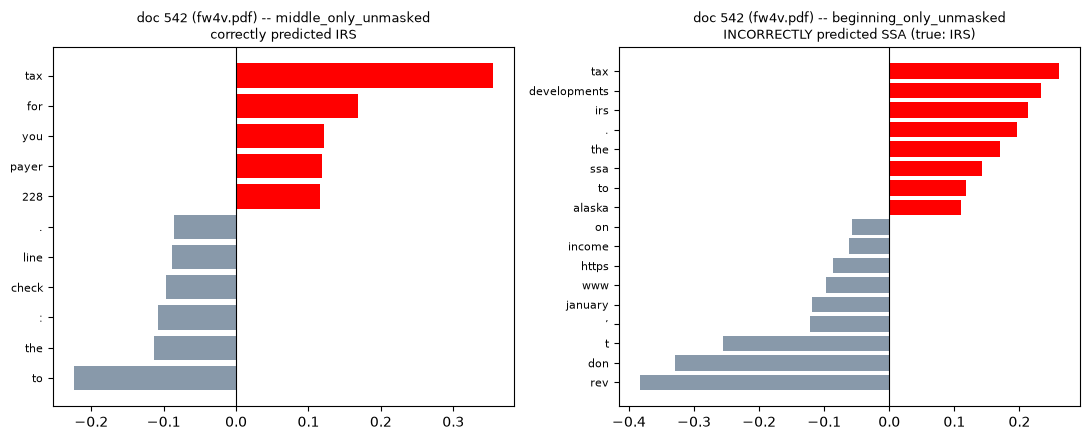

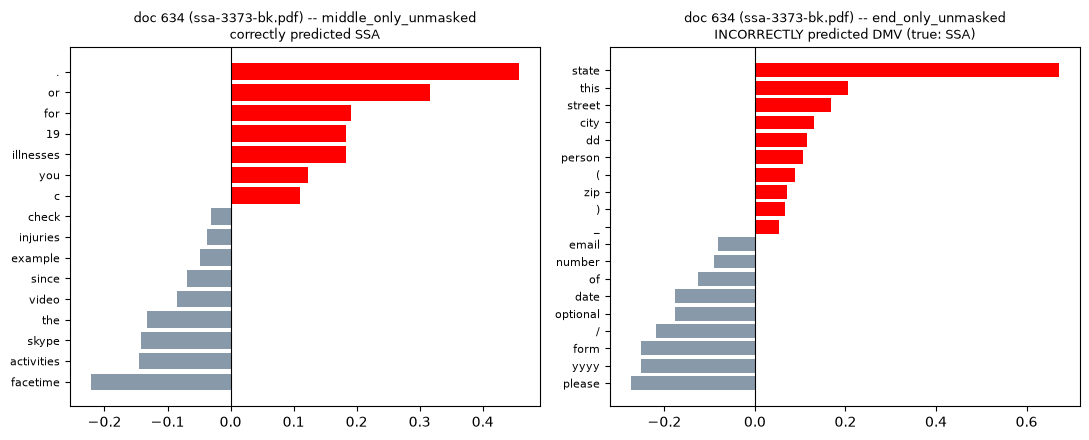

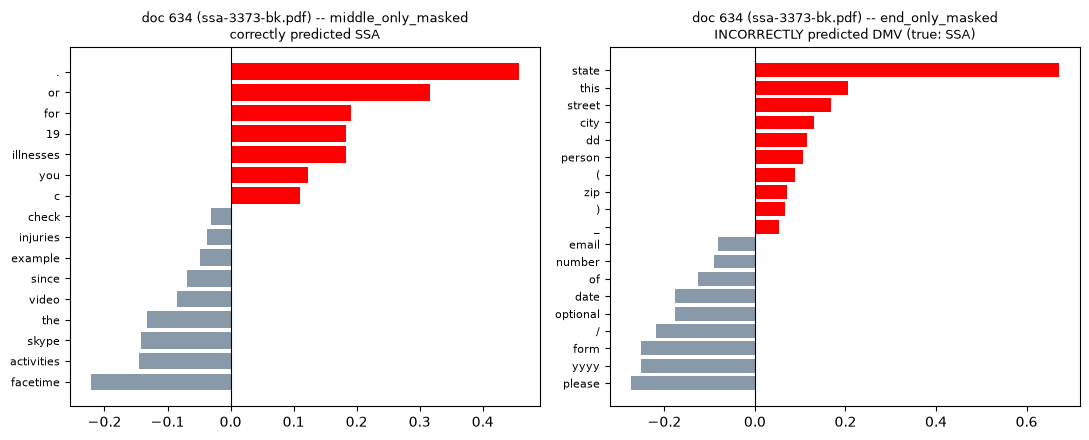

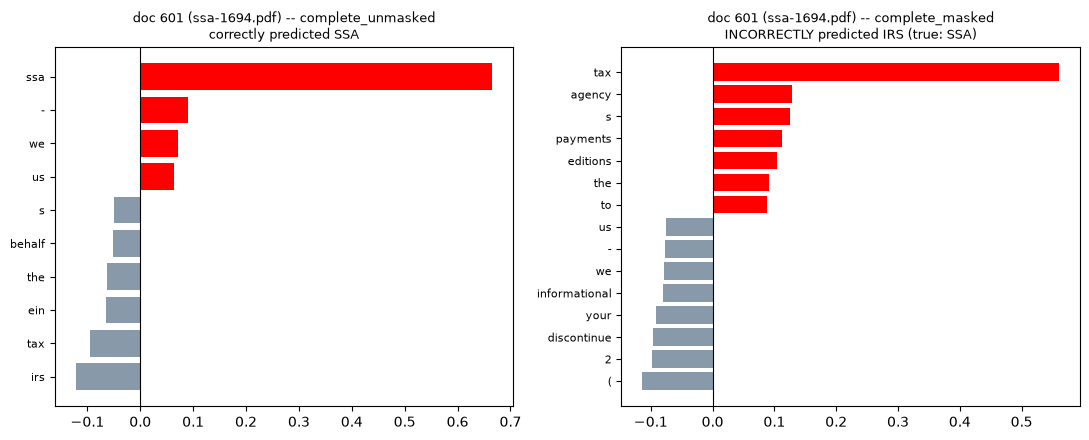

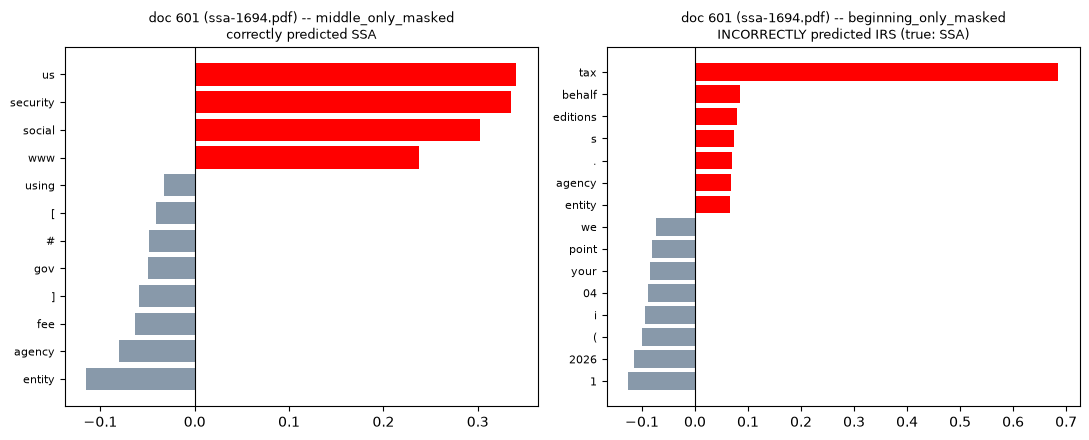

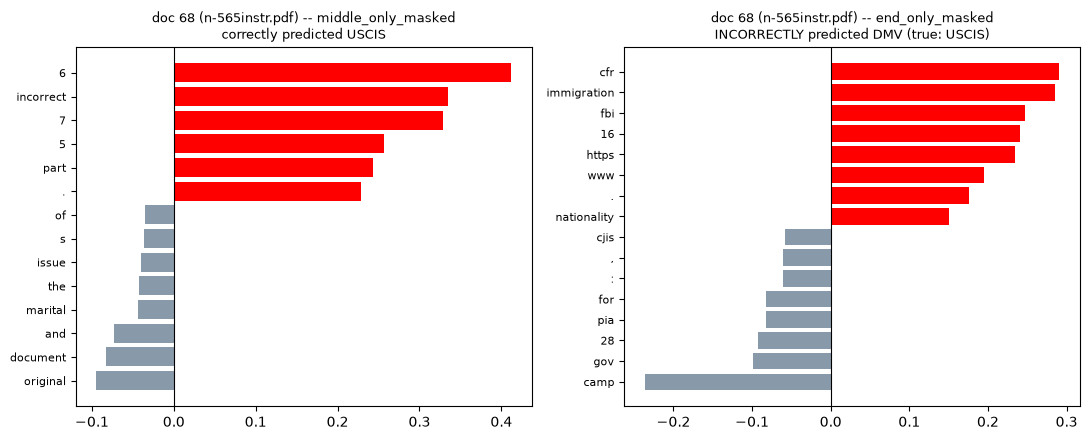

In [5]:
def plot_case(ax, df, title, top_n=10):
    top = pd.concat([df.head(top_n), df.tail(top_n)]).drop_duplicates(subset="word").sort_values("attribution")
    colors = ["red" if v > 0 else "#8899aa" for v in top["attribution"]]
    ax.barh(top["word"], top["attribution"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

for i, case in enumerate(CASES):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_case(
        axes[0], results[i]["correct"],
        f"doc {case['document_id']} ({case['filename']}) -- {case['correct_condition']}\ncorrectly predicted {case['correct_predicted_label']}",
    )
    plot_case(
        axes[1], results[i]["error"],
        f"doc {case['document_id']} ({case['filename']}) -- {case['error_condition']}\nINCORRECTLY predicted {case['error_predicted_label']} (true: {case['true_label']})",
    )
    plt.tight_layout()
    plt.show()

## Which agency-identifying cues were removed, and what took their place?

A small curated list of literal agency-identifying strings -- names, abbreviations, and this
document's own form number -- checked for presence in each condition's raw text, and for
whether they appear among that condition's top-10 positively attributed words (i.e., whether
the model actually leaned on them when they were present).

In [6]:
AGENCY_CUES = {
    "SSA": ["social security", "ssa"],
    "IRS": ["internal revenue", "irs", "treasury"],
    "DMV": ["motor vehicle", "dmv", "department of motor"],
    "USCIS": ["citizenship", "immigration", "uscis"],
}

cue_rows = []
for i, case in enumerate(CASES):
    for role, text_key, df_key in [("correct", "correct_text", "correct"), ("error", "error_text", "error")]:
        text_lower = case[text_key].lower()
        top_words_lower = set(w.lower() for w in results[i][df_key].head(10)["word"])
        for agency, cues in AGENCY_CUES.items():
            present_in_text = any(cue in text_lower for cue in cues)
            present_in_top_words = any(any(cue in w for cue in cues) for w in top_words_lower)
            if present_in_text or present_in_top_words:
                cue_rows.append({
                    "document_id": case["document_id"], "role": role, "condition": case[f"{role}_condition"],
                    "agency_cue_checked": agency, "cue_text_present": present_in_text,
                    "cue_in_top10_attributed_words": present_in_top_words,
                })

pd.DataFrame(cue_rows)

,document_id,role,condition,agency_cue_checked,cue_text_present,cue_in_top10_attributed_words
0,542,correct,middle_only_unmasked,IRS,True,False
1,542,error,beginning_only_unmasked,SSA,True,True
2,542,error,beginning_only_unmasked,IRS,True,True
3,601,correct,complete_unmasked,SSA,True,True
4,601,correct,complete_unmasked,IRS,True,False
5,601,error,complete_masked,SSA,True,False
6,601,error,complete_masked,IRS,True,False
7,601,correct,middle_only_masked,SSA,True,False
8,601,error,beginning_only_masked,SSA,True,False
9,68,correct,middle_only_masked,USCIS,True,False


## Summary

- Every reproduced prediction matched the real, saved Checkpoint 8 result exactly before any
  attribution was computed -- the explanations below describe predictions this notebook
  independently verified, not assumed.
- Integrated Gradients, not attention or word frequency, was used to attribute each
  prediction to specific words, following standard interpretability practice for
  transformer classifiers.
- For each erroring case, compare its panel above against the same document's correctly
  classified panel: the correct panel's positively-attributed words are frequently direct
  agency cues (the agency's name, "social security", "motor vehicle", form-number digits);
  the erroring panel's positively-attributed words are, case by case, either generic
  administrative language with no surviving agency cue, or words belonging to a different
  agency's typical vocabulary that happened to appear in that particular excerpt.
- This is a single-run, observational analysis on 6 real errors out of 990 evaluated cases --
  informative about *these specific* misclassifications, not a general causal claim about
  BERT's behavior on unseen data.